# ECE1508 - Course Project
##  Federated Learning Architectures for WiFi-Based Human Activity Recognition

## 1. Setup & Imports

In [118]:
import numpy as np
import os
import glob
import networkx as nx
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, Dataset, WeightedRandomSampler
from torchvision.models import resnet50, densenet121
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 2. Data Loading & Preprocessing

- Each sample is a CSI matrix of shape 1 × 250 × 90 (channels × time steps × subcarriers).
- Data are min-max normalised to [0, 1].
- There are 7 activity classes: lying down, falling, walking, running, sitting down, standing up, and background.

In [8]:
def load_UT_HAR(root_dir):
    expected = ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
    data = {}
    for folder in ["data", "label"]:
        files = glob.glob(os.path.join(root_dir, folder, "*.csv"))
        for path in files:
            key = os.path.basename(path).split(".")[0]
            if key not in expected:
                continue
            arr = np.load(path, allow_pickle=True)
            if folder == "data":
                arr = arr.reshape(len(arr), 1, 250, 90)
                arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
                arr = torch.tensor(arr, dtype=torch.float32)
            else:
                arr = torch.tensor(arr, dtype=torch.long)
            data[key] = arr
    return data

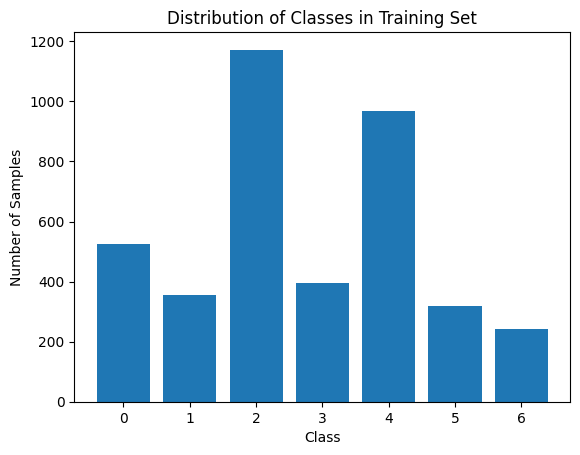

X_train shape: torch.Size([3977, 1, 250, 90])


In [9]:
wifi = load_UT_HAR("UT_HAR")

# Plot distribution of classes in training set
unique, counts = np.unique(wifi["y_train"].numpy(), return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classes in Training Set")
plt.show()

# Print shapes of datasets
print("X_train shape:", wifi["X_train"].shape)

- Dataset is relitively small and its distribution is imbalanced. We will use data augmentation and weighted sampler to increase the size of the training set and balance the classes.

In [12]:
class DataAugmentation:
    def __init__(self, noise=0.01, max_shift=5, scale_range=(0.9, 1.1)):
        self.noise = noise
        self.max_shift = max_shift
        self.scale_range = scale_range

    def __call__(self, x):
        x = x + self.noise * torch.randn_like(x)
        shift = torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item()
        x = torch.roll(x, shifts=shift, dims=2)
        x = x * torch.empty(1).uniform_(*self.scale_range).item()
        return x

def expand_dataset(data, labels, augmenter, factor=1):
    augmented_data = []
    augmented_labels = []

    for _ in range(factor):
        for x, y in zip(data, labels):
            x_aug = augmenter(x)
            augmented_data.append(x_aug.unsqueeze(0))
            augmented_labels.append(y.unsqueeze(0))

    new_data = torch.cat([data] + augmented_data, dim=0)
    new_labels = torch.cat([labels] + augmented_labels, dim=0)
    return new_data, new_labels
    
def get_weight(labels):
    classes, counts = torch.unique(labels, return_counts=True)
    total_count = len(labels)
    class_weights = total_count / (len(classes) * counts.float())
    sample_weights = class_weights[labels]
    return sample_weights

def data_loader(data, labels, factor=0, batch_size=64, shuffle=True, augmenter=None):
    if augmenter is not None:
        data, labels = expand_dataset(data, labels, augmenter, factor=factor)
    dataset = TensorDataset(data, labels)
    if shuffle:
        sample_weights = get_weight(labels)
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    else:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [ ]:
augmenter = DataAugmentation(noise=0.02, max_shift=5, scale_range=(0.9, 1.1))

X_train, y_train = wifi['X_train'], wifi['y_train']
X_val, y_val = wifi['X_val'], wifi['y_val']
X_test, y_test = wifi['X_test'], wifi['y_test']

NUM_CLASSES = int(y_train.max().item()) + 1

# Due to speed constrains, factor is set to 0 for now. You can increase it to 1 or 2 for better performance at the cost of longer training time.
train_loader = data_loader(X_train, y_train, factor=0, batch_size=64, shuffle=True, augmenter=augmenter)
val_loader = data_loader(X_val, y_val, batch_size=64, shuffle=False, augmenter=None)
test_loader = data_loader(X_test, y_test, batch_size=64, shuffle=False, augmenter=None)

Train batches: 63, Val batches: 8, Test batches: 8
Images shape: torch.Size([64, 1, 250, 90])
Labels shape: torch.Size([64])
Label values: tensor([0, 1, 2, 3, 4, 5, 6])


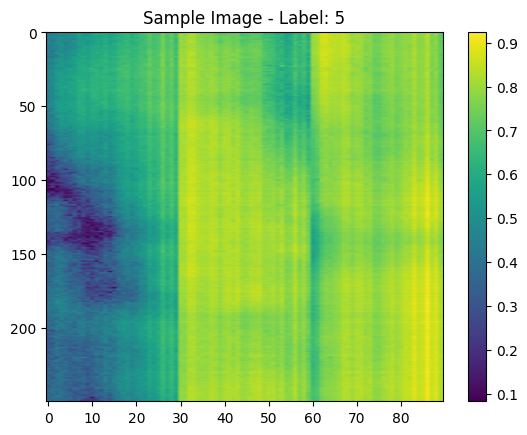

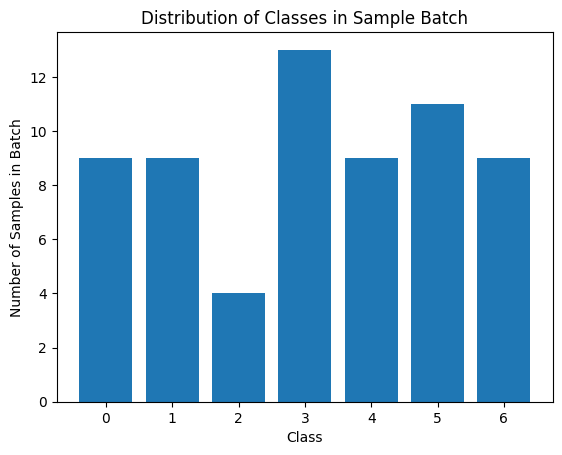

In [ ]:
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label values:", labels.unique())

sample_image, sample_label = images[0], labels[0]
plt.imshow(sample_image.squeeze(), aspect='auto', cmap='viridis')
plt.title(f"Sample Image - Label: {sample_label.item()}")
plt.colorbar()
plt.show()

batch_labels = labels.numpy()
unique, counts = np.unique(batch_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples in Batch")
plt.title("Distribution of Classes in Sample Batch")
plt.show()

## 3. Model Definitions

### 3.1. Custom CNN

In [104]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 31 * 11, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

### 3.2. ResNet-50

In [105]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = resnet50(weights=None)
        self.base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.fc = nn.Linear(self.base.fc.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

### 3.3. DenseNet-121

In [106]:
class DenseNetModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = densenet121(weights=None)
        self.base.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.classifier = nn.Linear(self.base.classifier.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

In [107]:
MODEL_BUILDERS = {
    'CNN': lambda: CNNModel(NUM_CLASSES),
    'ResNet50': lambda: ResNet50Model(NUM_CLASSES),
    'DenseNet': lambda: DenseNetModel(NUM_CLASSES),
}

MODELS = list(MODEL_BUILDERS.keys())

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print('Model Parameter Counts')
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    print(f'{name} params: {count_params(m)/1e6:.2f} M')

Model Parameter Counts
CNN params: 2.82 M
ResNet50 params: 23.52 M
DenseNet params: 6.95 M


## 4. Hyperparameter Tuning

In [ ]:
def hyper_train(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/n_batches:.4f}, Train Accuracy: {train_acc:.2f}%")

    return model, total_loss / max(n_batches, 1), train_acc

In [48]:
# Evaluation
@torch.no_grad()
def hyper_evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    loss = 0.0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss += nn.CrossEntropyLoss()(outputs, y).item()
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    return loss / len(loader), acc

In [ ]:
cnn_model = CNNModel(num_classes=7).to(device)
cnn_train_loss = hyper_train(
    model=cnn_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

cnn_test_loss, cnn_test_acc = hyper_evaluate(
    model=cnn_model,
    loader=val_loader,
)

print(f"Validation loss: {cnn_test_loss:.4f}, Validation accuracy: {cnn_test_acc:.2f}%")

Epoch 1/5 - Loss: 1.7367, Train Accuracy: 32.26%
Epoch 2/5 - Loss: 1.4931, Train Accuracy: 55.32%
Epoch 3/5 - Loss: 1.2932, Train Accuracy: 67.74%
Epoch 4/5 - Loss: 1.1482, Train Accuracy: 74.35%
Epoch 5/5 - Loss: 1.0306, Train Accuracy: 80.29%
Validation loss: 0.5395, Validation accuracy: 80.44%


### 4.1. Random Grid Search

In [88]:
def cnn_random_grid_search(options, model_name, num_trials):
    best_acc = 0
    best_config = None
    for trial in range(num_trials):
        t_lr = np.random.choice(options["lr_options"])
        t_batch_size = np.random.choice(options["batch_size_options"])
        t_epochs = np.random.choice(options["epoch_options"])

        print(f"\nTrial {trial+1}: lr={t_lr}, batch_size={t_batch_size}, epochs={t_epochs}")
        
        match model_name:
            case "cnn":
                model = CNNModel(num_classes=7).to(device)
            case "resnet":
                model = ResNet50Model(num_classes=7).to(device)
            case "densenet":
                model = DenseNetModel(num_classes=7).to(device)
        
        trial_train_dataset = data_loader(X_train, y_train, factor=0, batch_size=int(t_batch_size), shuffle=True, augmenter=augmenter)
        trial_val_dataset = data_loader(X_val, y_val, batch_size=int(t_batch_size), shuffle=False, augmenter=None)
        
        hyper_train(model=model, loader=trial_train_dataset, epochs=t_epochs, lr=t_lr)
        val_loss, val_acc = hyper_evaluate(model=model, loader=trial_val_dataset)
        
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_config = {"lr": t_lr, "batch_size": t_batch_size, "epochs": t_epochs}

    print(f"\nBest config: {best_config}, Validation Accuracy: {best_acc:.4f}")

In [89]:
options = {
    "lr_options": [0.0001, 0.005, 0.001, 0.01],
    "batch_size_options": [32, 64, 128],
    "epoch_options": [5]
}
cnn_random_grid_search(options, "cnn", num_trials=5)


Trial 1: lr=0.0001, batch_size=64, epochs=5
Epoch 1/5 - Loss: 1.9358, Train Accuracy: 20.09%
Epoch 2/5 - Loss: 1.8720, Train Accuracy: 32.71%
Epoch 3/5 - Loss: 1.7557, Train Accuracy: 47.80%
Epoch 4/5 - Loss: 1.6509, Train Accuracy: 54.11%
Epoch 5/5 - Loss: 1.5761, Train Accuracy: 57.25%
Validation Loss: 1.2398, Validation Accuracy: 50.60%

Trial 2: lr=0.01, batch_size=64, epochs=5
Epoch 1/5 - Loss: 2.5768, Train Accuracy: 14.46%
Epoch 2/5 - Loss: 2.2618, Train Accuracy: 14.66%
Epoch 3/5 - Loss: 2.1567, Train Accuracy: 14.86%
Epoch 4/5 - Loss: 2.1041, Train Accuracy: 15.36%
Epoch 5/5 - Loss: 2.0726, Train Accuracy: 14.68%
Validation Loss: 1.9356, Validation Accuracy: 9.88%

Trial 3: lr=0.005, batch_size=64, epochs=5
Epoch 1/5 - Loss: 1.9701, Train Accuracy: 14.56%
Epoch 2/5 - Loss: 1.7856, Train Accuracy: 37.64%
Epoch 3/5 - Loss: 1.5587, Train Accuracy: 59.24%
Epoch 4/5 - Loss: 1.3433, Train Accuracy: 75.41%
Epoch 5/5 - Loss: 1.1759, Train Accuracy: 82.95%
Validation Loss: 0.4922, Val

- Among the tested hyperparameter configurations, a learning rate of 0.001 with batch size 64 was selected as the optimal setting. Although a higher learning rate (0.005) achieved slightly better peak validation accuracy, the configuration with 0.001 provided more stable and consistent training behavior, making it a more reliable choice for downstream experiments.

- Higher learning rates (0.01) failed to converge, while very low learning rates (0.0001) resulted in slow learning and underfitting. The learning rate of 0.001 achieved a strong balance between convergence speed and stability.

In [91]:
cnn_model = CNNModel(num_classes=7).to(device)
train_loader = data_loader(X_train, y_train, factor=0, batch_size=64, shuffle=True, augmenter=augmenter)
test_loader = data_loader(X_test, y_test, batch_size=64, shuffle=False, augmenter=None)
cnn_train_loss = hyper_train(
    model=cnn_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

cnn_test_loss, cnn_test_acc = hyper_evaluate(
    model=cnn_model,
    loader=test_loader,
)

print(f"Test loss: {cnn_test_loss:.4f}, Test accuracy: {cnn_test_acc:.2f}%")

Epoch 1/5 - Loss: 1.7181, Train Accuracy: 33.47%
Epoch 2/5 - Loss: 1.4652, Train Accuracy: 55.87%
Epoch 3/5 - Loss: 1.2735, Train Accuracy: 68.22%
Epoch 4/5 - Loss: 1.1225, Train Accuracy: 76.49%
Epoch 5/5 - Loss: 0.9967, Train Accuracy: 82.50%
Test loss: 0.6553, Test accuracy: 77.80%


## 5. Utility Functions

In [96]:
# Local training step
def train_local(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)

    return model, total_loss / max(n_batches, 1), train_acc

In [97]:
# Evaluation
@torch.no_grad()
def evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1

In [98]:
# FedAvg aggregation
def fedavg_aggregate(global_model, client_models, weights=None):

    K = len(client_models)
    if weights is None:
        weights = [1.0 / K] * K
    global_sd = global_model.state_dict()
    client_sds = [m.state_dict() for m in client_models]
    for key in global_sd:
        if global_sd[key].dtype.is_floating_point:
            global_sd[key] = sum(w * sd[key] for w, sd in zip(weights, client_sds))
        else:
            global_sd[key] = client_sds[0][key]
    global_model.load_state_dict(global_sd)
    return global_model

In [99]:
# Communication cost
def model_size_M(model):
    return count_params(model) / 1e6

## 6. Client Data Partitioning

- The training set is split into K equal IID partitions, one per client.

In [94]:
def iid_partition(dataset, K, batch_size=64):

    n = len(dataset)
    indices = torch.randperm(n).tolist()
    splits = np.array_split(indices, K)
    loaders = []
    for idx in splits:
        subset = Subset(dataset, idx.tolist())
        loaders.append(DataLoader(subset, batch_size=batch_size, shuffle=True))
    return loaders

## 7. Centralized Federated Learning (FedAvg)

- Protocol per round:
  1. Broadcast global model to all K clients.
  2. Each client trains locally for E epochs.
  3. Server collects and averages all client models.
- Communication cost per round: 2 × K × |θ| (K uploads + K downloads).

In [ ]:
def run_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_loader.dataset, K, batch_size)
    global_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(global_model)
    comm_per_round = 2 * K * params

    round_local_train_acc = []
    round_global_train_acc = []
    round_acc = []
    round_f1 = []

    for t in range(1, T + 1):
        client_models = []
        client_train_accs = []
        for loader in client_loaders:
            client = copy.deepcopy(global_model)
            client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
            client_models.append(client)
            client_train_accs.append(train_acc)

        global_model = fedavg_aggregate(global_model, client_models)
        local_avg_train_acc = sum(client_train_accs) / len(client_train_accs)
        global_train_acc, _ = evaluate(global_model, train_loader)
        acc, f1 = evaluate(global_model, test_loader)

        round_local_train_acc.append(local_avg_train_acc)
        round_global_train_acc.append(global_train_acc)
        round_acc.append(acc)
        round_f1.append(f1)
        print(
            f'Round {t:2d}/{T}  '
            f'LocalAvgTrain={local_avg_train_acc:.2f}%  '
            f'GlobalTrain={global_train_acc:.2f}%  '
            f'GlobalTest={acc:.2f}%  '
            f'F1={f1:.4f}'
        )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_local_train_acc': round_local_train_acc,
        'round_global_train_acc': round_global_train_acc,
        'round_acc': round_acc,
        'round_f1': round_f1,
        'final_acc': round_acc[-1],
        'final_f1': round_f1[-1],
        'comm_M': total_comm,
        'model': global_model
    }

### 7.1. Run Experiments
- **Experiment Configuration**
  - K: Total number of clients
  - T: Number of global communication rounds
  - E: Local training epochs per round per client
  - batch_size: Mini-batch size during local training
  - lr: Learning rate for Adam optimiser

In [14]:
K = 10
T = 10
E = 5
batch_size = 64
lr = 1e-3

results = {}

print('Experiment Configuration')
print(f'K={K}, T={T}, E={E}, batch_size={batch_size}, lr={lr}')

Experiment Configuration
K=10, T=10, E=5, batch_size=64, lr=0.001


- **Model Training**

In [15]:
print('Centralized FL')

for model_name in MODELS:
    results.setdefault(model_name, {})
    print('-' * 60)
    print(f'Model: {model_name}')
    print()
    results[model_name]['FedAvg'] = run_fedavg(model_name, K=K, T=T, E=E, batch_size=batch_size, lr=lr)

Centralized FL
------------------------------------------------------------
Model: CNN

Round  1/10  LocalAvgTrain=34.27%  GlobalTrain=29.44%  GlobalTest=29.80%  F1=0.0698
Round  2/10  LocalAvgTrain=49.91%  GlobalTrain=50.04%  GlobalTest=49.40%  F1=0.3436
Round  3/10  LocalAvgTrain=58.38%  GlobalTrain=57.58%  GlobalTest=54.80%  F1=0.4548
Round  4/10  LocalAvgTrain=65.65%  GlobalTrain=66.11%  GlobalTest=63.20%  F1=0.5752
Round  5/10  LocalAvgTrain=72.47%  GlobalTrain=71.94%  GlobalTest=68.40%  F1=0.6275
Round  6/10  LocalAvgTrain=76.92%  GlobalTrain=76.14%  GlobalTest=72.00%  F1=0.6573
Round  7/10  LocalAvgTrain=82.02%  GlobalTrain=80.04%  GlobalTest=76.20%  F1=0.7162
Round  8/10  LocalAvgTrain=85.49%  GlobalTrain=83.38%  GlobalTest=78.80%  F1=0.7492
Round  9/10  LocalAvgTrain=88.59%  GlobalTrain=85.79%  GlobalTest=80.20%  F1=0.7640
Round 10/10  LocalAvgTrain=89.79%  GlobalTrain=87.13%  GlobalTest=83.00%  F1=0.7958
Total comm cost: 564.5 M params
----------------------------------------

### 7.2. Results & Visualisation

- Summary table

In [16]:
print('Final Results Summary')
print(f"{'Model':<12} {'Acc (%)':>8} {'Macro-F1':>10} {'Comm (M params)':>18}")
for model_name in MODELS:
    r = results[model_name]['FedAvg']
    print(f"{model_name:<12} {r['final_acc']:>8.2f} {r['final_f1']:>10.4f} {r['comm_M']:>18.1f}")

Final Results Summary
Model         Acc (%)   Macro-F1    Comm (M params)
CNN             83.00     0.7958              564.5
ResNet50        93.40     0.9140             4703.2
DenseNet        93.40     0.9341             1391.0


- Convergence plots: LocalAvgTrain, GlobalTrain, GlobalTest

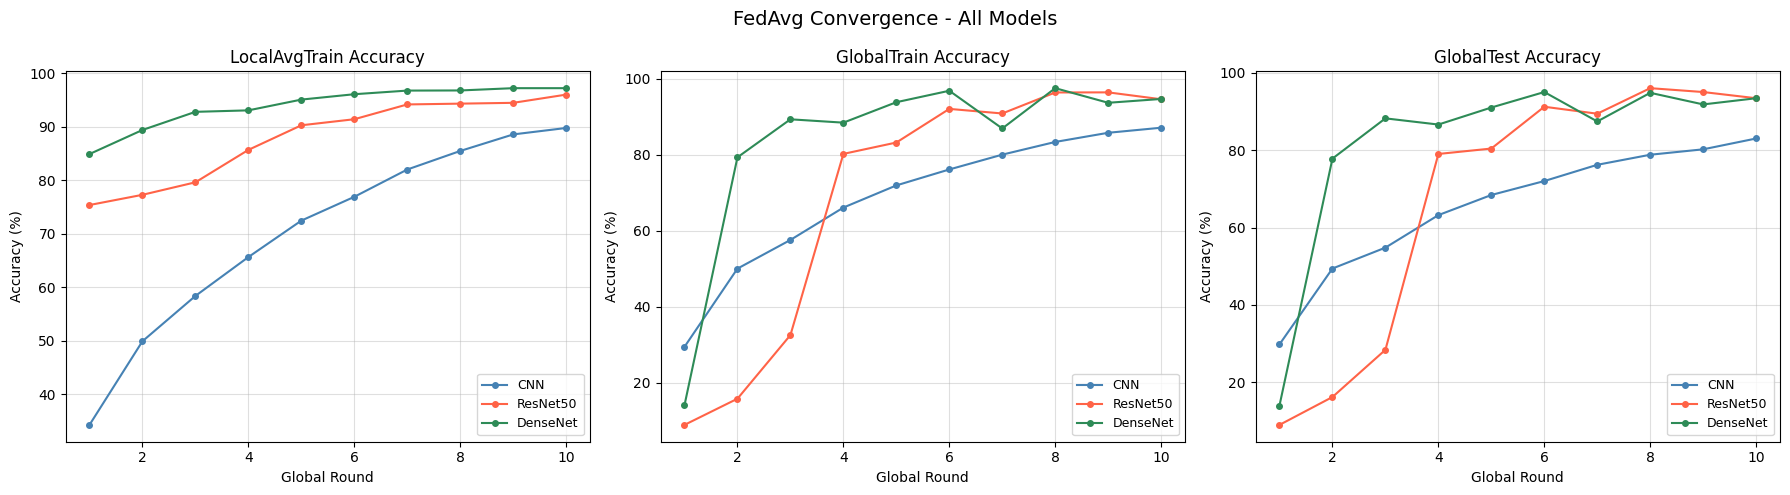

In [17]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'steelblue', 'ResNet50': 'tomato', 'DenseNet': 'seagreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
titles = ['LocalAvgTrain Accuracy', 'GlobalTrain Accuracy', 'GlobalTest Accuracy']
keys = ['round_local_train_acc', 'round_global_train_acc', 'round_acc']

for ax, title, key in zip(axes, titles, keys):
    for model_name in MODELS:
        r = results[model_name]['FedAvg']
        ax.plot(rounds, r[key], color=colors[model_name], marker='o', markersize=4, label=model_name)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle('FedAvg Convergence - All Models', fontsize=14)
plt.tight_layout()
plt.show()

- Macro-F1 convergence

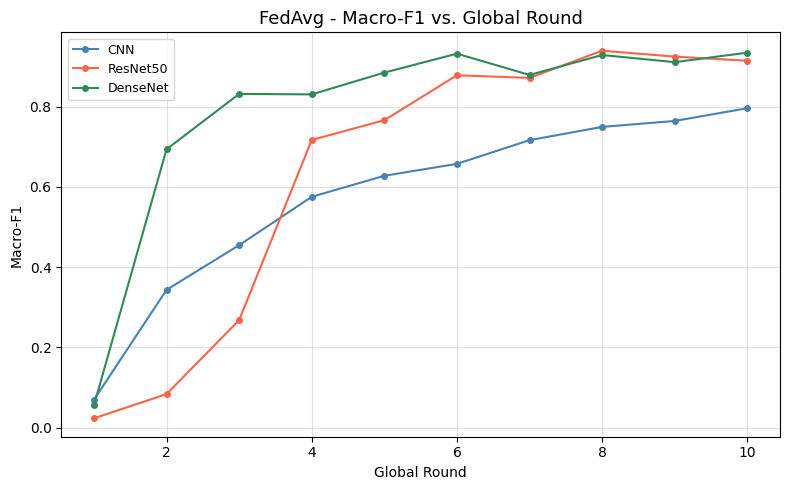

In [18]:
rounds = list(range(1, T + 1))
fig, ax = plt.subplots(figsize=(8, 5))

for model_name in MODELS:
    r = results[model_name]['FedAvg']
    ax.plot(rounds, r['round_f1'], color=colors[model_name], marker='o', markersize=4, label=model_name)

ax.set_title('FedAvg - Macro-F1 vs. Global Round', fontsize=13)
ax.set_xlabel('Global Round')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

- Bar chart: final accuracy and F1

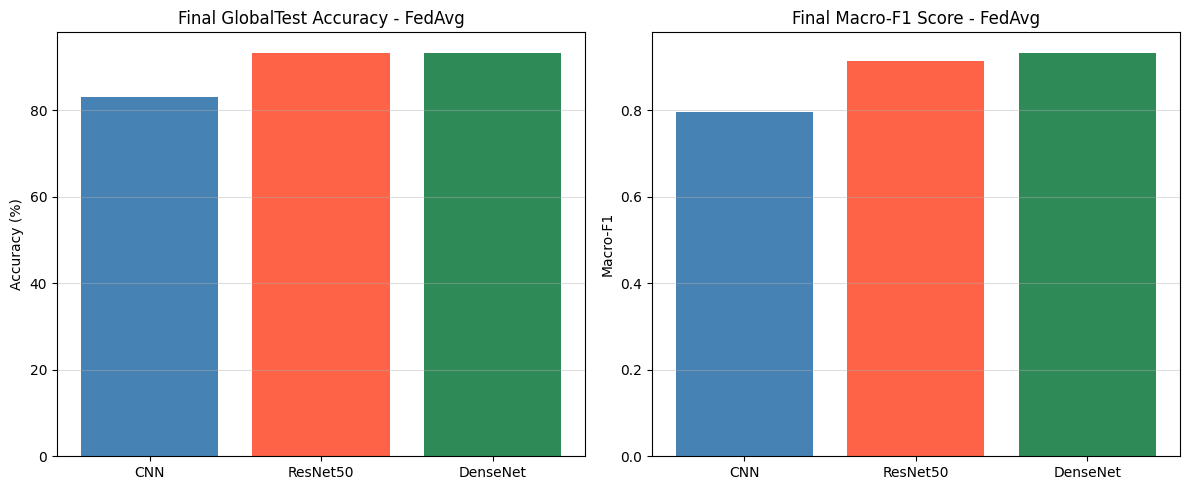

In [19]:
x = np.arange(len(MODELS))
color_list = [colors[m] for m in MODELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

accs = [results[m]['FedAvg']['final_acc'] for m in MODELS]
f1s = [results[m]['FedAvg']['final_f1'] for m in MODELS]

ax1.bar(x, accs, color=color_list)
ax2.bar(x, f1s, color=color_list)

for ax, ylabel, title in [
    (ax1, 'Accuracy (%)', 'Final GlobalTest Accuracy - FedAvg'),
    (ax2, 'Macro-F1', 'Final Macro-F1 Score - FedAvg')
]:
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

## 8. Decentralized Federated Learning (Graph-based)
- Protocol per round:
  1. Each client sends its current model to its two neighbors in the ring.
  2. Each client receives models from its neighbors and aggregates them (e.g., FedAvg with self + neighbors).
  3. Each client trains locally for E epochs using its updated model.
- Communication cost per round: 2 × K × |θ| (each client uploads 2 times to both its neighbors).

In [122]:
def create_graph(num_clients):
    G = nx.Graph()
    # Add client nodes
    for i in range(num_clients):
        G.add_node(f'Client {i+1}')
    # Add ring edges
    for i in range(num_clients):
        G.add_edge(f'Client {i+1}', f'Client {(i+2) % num_clients + 1}')
    return G

In [138]:
def run_ring_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_loader.dataset, K, batch_size)
    initial_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(initial_model)
    comm_per_round = 2 * K * params

    G = create_graph(K)
    
    client_models = []
    round_acc = []
    round_f1 = []

    for t in range(1, T + 1):
        client_train_accs = 0.0
        client_test_accs = 0.0
        client_test_f1s = 0.0
        
        if t == 1:
            init_client_train_accs = 0.0
            # Each client trains on its local data and sends model to neighbors
            for loader in client_loaders:
                client = copy.deepcopy(initial_model)
                client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
                client_models.append(client)
                init_client_train_accs += train_acc
            
        # Each client aggregates models from neighbors and updates its model
        for node in G.nodes:
            neighbors = list(G.neighbors(node))
            neighbor_indexes = [int(n.split()[1]) - 1 for n in neighbors]
            neighbor_models = [client_models[i] for i in neighbor_indexes]
            idx = int(node.split()[1]) - 1
            client_models[idx] = fedavg_aggregate(client_models[idx], neighbor_models)
            
        # Train each client on its local data with the aggregated model
        for model in client_models:
            idx = client_models.index(model)
            loader = client_loaders[idx]
            model, _, train_acc = train_local(model, loader, epochs=E, lr=lr)
            client_train_accs += train_acc

        # Evaluate client's model on test set
        for model in client_models:
            acc, f1 = evaluate(model, test_loader)
            client_test_accs += acc
            client_test_f1s += f1
        
        round_acc.append(client_test_accs / K)
        round_f1.append(client_test_f1s / K)

        if t == 1:
             print(
                f'Round {t:2d}/{T}  '
                f'InitClientAvgTrain={init_client_train_accs/K:.2f}%  '
                f'ClientAvgTrain={client_train_accs/K:.2f}%  '
                f'ClientAvgTest={round_acc[-1]:.2f}%  '
                f'F1={round_f1[-1]:.4f}'
            )
        else:
            print(
                f'Round {t:2d}/{T}  '
                f'ClientAvgTrain={client_train_accs/K:.2f}%  '
                f'ClientAvgTest={round_acc[-1]:.2f}%  '
                f'F1={round_f1[-1]:.4f}'
            )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_acc': round_acc,
        'round_f1': round_f1,
        'final_acc': round_acc[-1],
        'final_f1': round_f1[-1],
        'comm_M': total_comm,
    }

### 8.1. Run Experiments

In [134]:
K = 3
T = 10
E = 5
batch_size = 64
lr = 1e-3

results = {}

print(f'Experiment Configuration: Number of Clients={K}, Rounds={T}, Epochs={E}, batch_size={batch_size}, lr={lr}')

Experiment Configuration: Number of Clients=3, Rounds=10, Epochs=5, batch_size=64, lr=0.001


In [139]:
# for model_name in MODELS:
#     results.setdefault(model_name, {})
#     print('-' * 60)
#     print(f'Model: {model_name}')
#     print()
#     results[model_name]['GraphBased'] = run_ring_fedavg(model_name, K=K, T=T, E=E, batch_size=batch_size, lr=lr)

run_ring_fedavg("CNN", K=K, T=T, E=E, batch_size=batch_size, lr=lr)

Round  1/10  InitClientAvgTrain=55.04%  ClientAvgTrain=73.12%  ClientAvgTest=66.93%  F1=0.6058
Round  2/10  ClientAvgTrain=85.57%  ClientAvgTest=77.60%  F1=0.7268
Round  3/10  ClientAvgTrain=93.21%  ClientAvgTest=84.07%  F1=0.8095
Round  4/10  ClientAvgTrain=95.25%  ClientAvgTest=85.87%  F1=0.8250
Round  5/10  ClientAvgTrain=97.54%  ClientAvgTest=88.93%  F1=0.8592
Round  6/10  ClientAvgTrain=97.89%  ClientAvgTest=89.73%  F1=0.8773
Round  7/10  ClientAvgTrain=98.89%  ClientAvgTest=92.00%  F1=0.8950
Round  8/10  ClientAvgTrain=99.17%  ClientAvgTest=91.40%  F1=0.8827
Round  9/10  ClientAvgTrain=99.32%  ClientAvgTest=93.33%  F1=0.9127
Round 10/10  ClientAvgTrain=99.47%  ClientAvgTest=93.60%  F1=0.9117
Total comm cost: 169.4 M params


{'round_acc': [np.float64(66.93333333333334),
  np.float64(77.60000000000001),
  np.float64(84.06666666666666),
  np.float64(85.86666666666667),
  np.float64(88.93333333333334),
  np.float64(89.73333333333333),
  np.float64(92.0),
  np.float64(91.40000000000002),
  np.float64(93.33333333333333),
  np.float64(93.60000000000001)],
 'round_f1': [0.6058224114796157,
  0.7268454228991814,
  0.8094503208146695,
  0.8250269761339798,
  0.8591844552526164,
  0.8772574826435638,
  0.895036612877726,
  0.8826970018349835,
  0.9127224124108871,
  0.9117315104466934],
 'final_acc': np.float64(93.60000000000001),
 'final_f1': 0.9117315104466934,
 'comm_M': 169.35402}